In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
# Upload your dataset in Colab or provide path
df = pd.read_csv("station_hour.csv")

print(df.head())
print(df.columns)

  StationId             Datetime  PM2.5    PM10    NO    NO2    NOx    NH3  \
0     AP001  2017-11-24 17:00:00  60.50   98.00  2.35  30.80  18.25   8.50   
1     AP001  2017-11-24 18:00:00  65.50  111.25  2.70  24.20  15.07   9.77   
2     AP001  2017-11-24 19:00:00  80.00  132.00  2.10  25.18  15.15  12.02   
3     AP001  2017-11-24 20:00:00  81.50  133.25  1.95  16.25  10.23  11.58   
4     AP001  2017-11-24 21:00:00  75.25  116.00  1.43  17.48  10.43  12.03   

    CO    SO2      O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  0.1  11.85  126.40      0.1     6.10    0.10  NaN        NaN  
1  0.1  13.17  117.12      0.1     6.25    0.15  NaN        NaN  
2  0.1  12.08   98.98      0.2     5.98    0.18  NaN        NaN  
3  0.1  10.47  112.20      0.2     6.72    0.10  NaN        NaN  
4  0.1   9.12  106.35      0.2     5.75    0.08  NaN        NaN  
Index(['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', '

In [3]:
df = df[df['StationId'] == 'AP001']

In [4]:
features = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
data = df[features]

In [5]:
data.fillna(method='ffill', inplace=True)
data.dropna(inplace=True)

/tmp/ipykernel_2554/9021023.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2554/9021023.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2554/9021023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [7]:
def create_sequences(data, look_back=24):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back, 0])  # PM2.5
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, 24)

In [8]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=10, batch_size=32,
          validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0015 - val_loss: 4.7067e-04
Epoch 2/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.1946e-04 - val_loss: 3.7951e-04
Epoch 3/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9570e-04 - val_loss: 3.4422e-04
Epoch 4/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5.4361e-04 - val_loss: 3.1454e-04
Epoch 5/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.0366e-04 - val_loss: 3.1545e-04
Epoch 6/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.9130e-04 - val_loss: 2.9537e-04
Epoch 7/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.7989e-04 - val_loss: 2.9699e-04
Epoch 8/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.6557e-04 - val_loss: 2.8585e-04
Epoch 9/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4.6633e-04 - val_loss: 2.7954e-04
Epoch 10/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 4.5882e-04 - val_loss: 2.7935e-04


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

y_test_inv = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test),7))], axis=1)
)[:,0]

y_pred_inv = scaler.inverse_transform(
    np.concatenate([y_pred, np.zeros((len(y_pred),7))], axis=1)
)[:,0]

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print("Delhi Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Delhi Results:
RMSE: 5.156221974436726
MAE: 3.482197633807168
R2: 0.9272217167948448


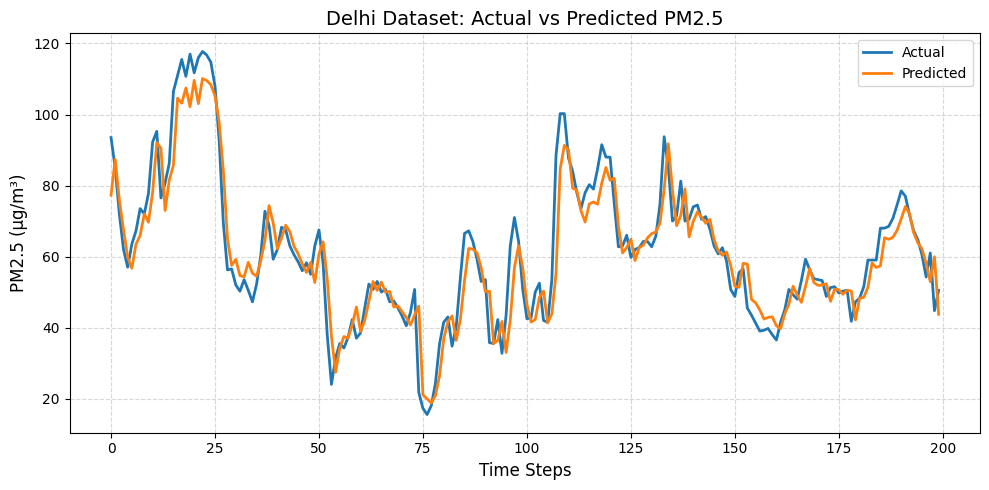

In [11]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv[:200], label='Actual', linewidth=2)
plt.plot(y_pred_inv[:200], label='Predicted', linewidth=2)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.title("Delhi Dataset: Actual vs Predicted PM2.5", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("PM2.5 (µg/m³)", fontsize=12)

plt.tight_layout()
plt.savefig("delhi_prediction.png", dpi=300)
plt.show()

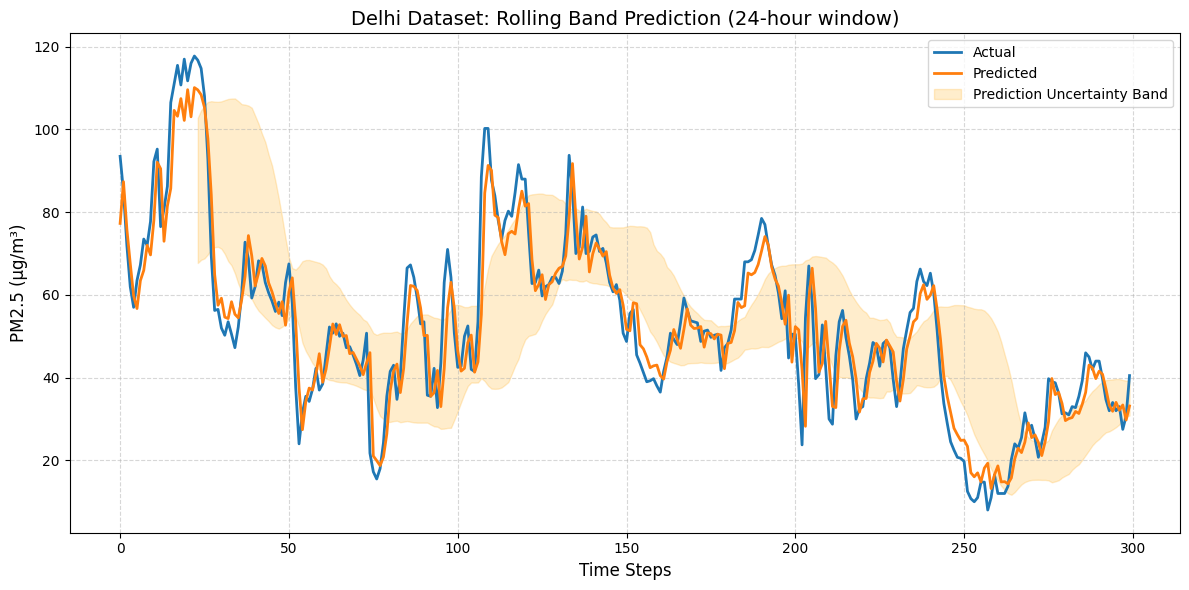

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to pandas series
actual_series = pd.Series(y_test_inv)
pred_series = pd.Series(y_pred_inv)

# Rolling window (same as paper: 24 hours)
window = 24

# Rolling statistics
rolling_mean = pred_series.rolling(window=window).mean()
rolling_std = pred_series.rolling(window=window).std()

# Upper and lower bands
upper_band = rolling_mean + rolling_std
lower_band = rolling_mean - rolling_std

# Plot
plt.figure(figsize=(12,6))

plt.plot(actual_series[:300], label='Actual', linewidth=2)
plt.plot(pred_series[:300], label='Predicted', linewidth=2)

plt.fill_between(range(len(rolling_mean[:300])),
                 lower_band[:300],
                 upper_band[:300],
                 color='orange', alpha=0.2,
                 label='Prediction Uncertainty Band')

plt.title("Delhi Dataset: Rolling Band Prediction (24-hour window)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("PM2.5 (µg/m³)", fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("delhi_rolling_band.png", dpi=300)
plt.show()